In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import reservoirpy as rpy
from reservoirpy.observables import nrmse, rsquare
from pandas import read_csv

rpy.set_seed(42)

In [2]:
data_time = read_csv('../Dataset/Lorenz_data.csv', usecols=[0])
time = data_time.values
time = time.astype('float32')

data_Lorenz = read_csv('../Dataset/Lorenz_data.csv', usecols=[1, 2, 3])
data_Lorenz = data_Lorenz.values
data_Lorenz = data_Lorenz.astype('float32')

data_Rossler = read_csv('../Dataset/Rossler_data.csv', usecols=[1, 2, 3])
data_Rossler = data_Rossler.values
data_Rossler = data_Rossler.astype('float32')

data_Chen = read_csv('../Dataset/Chen_data.csv', usecols=[1, 2, 3])
data_Chen = data_Chen.values
data_Chen = data_Chen.astype('float32')

data_Qi = read_csv('../Dataset/Qi_data.csv', usecols=[1, 2, 3])
data_Qi = data_Qi.values
data_Qi = data_Qi.astype('float32')

# data_noise_Lorenz = read_csv('../Dataset/noise_Lorenz_data.csv', usecols=[1, 2, 3])
# data_noise_Lorenz = data_noise_Lorenz.values
# data_noise_Lorenz = data_noise_Lorenz.astype('float32')

data_Chua = read_csv('../Dataset/Chua_data.csv', usecols=[1, 2, 3])
data_Chua = data_Chua.values
data_Chua = data_Chua.astype('float32')

In [3]:
from reservoirpy.datasets import to_forecasting

X = data_Chua
x, y = to_forecasting(X, forecast=1)
train_size = 4000
X_train1, y_train1 = x[:train_size], y[:train_size]
X_test1, y_test1 = x[train_size:], y[train_size:]
print(X_train1.shape, y_train1.shape)
print(X_test1.shape, y_test1.shape)


(4000, 3) (4000, 3)
(999, 3) (999, 3)


In [4]:
units = 4000
leak_rate = 0.3
spectral_radius = 1.25
input_scaling = 1.0
connectivity = 0.1
input_connectivity = 0.2
regularization = 1e-8
seed = 1234

In [5]:
def reset_esn():
    from reservoirpy.nodes import Reservoir, Ridge

    reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                          lr=leak_rate, rc_connectivity=connectivity,
                          input_connectivity=input_connectivity, seed=seed)
    readout   = Ridge(3, ridge=regularization)

    return reservoir >> readout

In [6]:
from reservoirpy.nodes import Reservoir, Ridge

reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                      lr=leak_rate, rc_connectivity=connectivity,
                      input_connectivity=input_connectivity, seed=seed)

readout   = Ridge(3, ridge=regularization)

esn = reservoir >> readout

In [7]:
y = esn(X[0])  # initialisation
reservoir.Win is not None, reservoir.W is not None, readout.Wout is not None

(True, True, True)

In [8]:
esn = esn.fit(X_train1, y_train1)

Running Model-0: 4000it [00:06, 640.72it/s]0<?, ?it/s]
Running Model-0: 100%|██████████| 1/1 [00:06<00:00,  6.92s/it]


Fitting node Ridge-0...


c:\Users\Rhyme\miniconda3\envs\CHAOS\Lib\site-packages\reservoirpy\nodes\readouts\ridge.py:17: LinAlgWarning: Ill-conditioned matrix (rcond=7.48057e-17): result may not be accurate.
  return linalg.solve(XXT + ridge, YXT.T, assume_a="sym")


In [9]:
y_pred1 = esn.run(X_test1)

Running Model-0: 999it [00:01, 647.03it/s]            


In [10]:
def plot_results(y_pred, y_test, sample=500):

    fig = plt.figure(figsize=(15, 7))
    plt.subplot(211)
    plt.plot(np.arange(sample), y_pred[:sample], lw=3, label="ESN prediction")
    plt.plot(np.arange(sample), y_test[:sample], linestyle="--", lw=2, label="True value")
    plt.plot(np.abs(y_test[:sample] - y_pred[:sample]), label="Absolute deviation")

    plt.legend()
    plt.show()
    
# plot_results(y_pred1, y_test1)

In [11]:
rsquare(y_test1, y_pred1), nrmse(y_test1, y_pred1)

(0.9994321947173838, 0.004671650791490839)

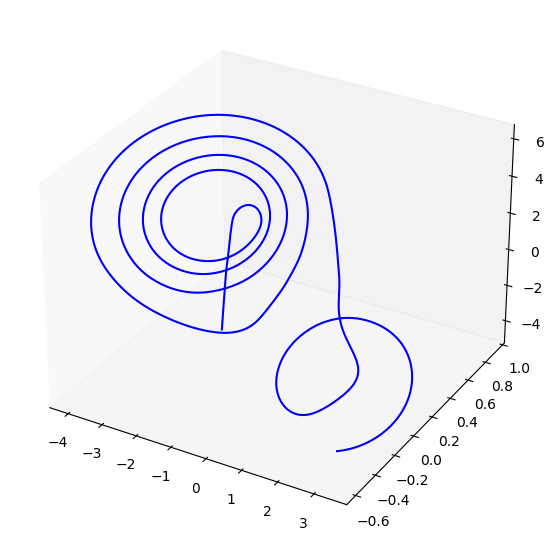

In [12]:
N = y_pred1.shape[0]
Y2 = y_test1
Y1 = y_pred1

fig = plt.figure(figsize=(15, 7))
ax1 = plt.subplot(121, projection='3d')
# for i in range(N-1):
#     ax1.plot(Y1[i:i+2, 0], Y1[i:i+2, 1], Y1[i:i+2, 2], color=plt.cm.magma(255*i//N), lw=1.0)
ax1.plot(Y1[:, 0], Y1[:, 1], Y1[:, 2], color='b')
ax1.grid(False)

# ax2 = plt.subplot(122, projection='3d')
# # for i in range(N-1):
# #     ax2.plot(Y2[i:i+2, 0], Y2[i:i+2, 1], Y2[i:i+2, 2], color=plt.cm.magma(255*i//N), lw=1.0)
# ax2.plot(Y2[:, 0], Y2[:, 1], Y2[:, 2], color='r')
# ax2.grid(False)